# 05 - Correlation and Statistical Analysis
**Project:** Air Quality & Pollution Intelligence - Data Mining and Business Intelligence

**Objective:** Quantify how the measured variables relate to each other and to AQI, test whether those relationships are real, and establish what the data can and cannot support.

**How to read this notebook:** every number printed below is produced by the
code in this notebook from `data/raw/Air_quality_data.csv`. Column names are
discovered at runtime through `src/config.py`, so nothing is assumed.


In [1]:
"""Environment bootstrap: make src/ importable and pin the working directory."""
import sys, os, warnings
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
%matplotlib inline
print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\OneDrive\Desktop\Air Quality


In [2]:
import config as C
import data_utils as U
import preprocessing as P
import feature_engineering as FE
import statistics_analysis as S
import figures as F
import viz as V
from IPython.display import display, Image

clean, *_ = P.clean(U.load_raw())
feat, _ = FE.build_features(clean)
polls = C.pollutant_columns(feat.columns)
meas = polls + [C.AQI_COL]
V.style()

## 1. Pearson correlation matrix

Pearson's r measures **linear** association only, on -1 to +1. It is sensitive to
outliers and blind to any curve that is not a straight line.

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
PM2.5,1.0000,-0.0248,-0.0031,0.0066,0.0030,0.0060,0.0096,0.0091,0.0085,-0.0097
PM10,-0.0248,1.0000,0.0024,0.0036,-0.0046,0.0008,-0.0074,0.0115,-0.0055,0.2296
NO,-0.0031,0.0024,1.0000,-0.0034,0.0013,0.0016,-0.0061,-0.0013,-0.0137,0.0026
NO2,0.0066,0.0036,-0.0034,1.0000,0.0015,-0.0060,0.0098,-0.0115,0.0034,0.0099
NOx,0.0030,-0.0046,0.0013,0.0015,1.0000,-0.0034,-0.0008,-0.0173,0.0059,-0.0079
NH3,0.0060,0.0008,0.0016,-0.0060,-0.0034,1.0000,-0.0039,0.0016,-0.0029,0.0005
CO,0.0096,-0.0074,-0.0061,0.0098,-0.0008,-0.0039,1.0000,-0.0044,-0.0011,0.0299
SO2,0.0091,0.0115,-0.0013,-0.0115,-0.0173,0.0016,-0.0044,1.0000,0.0005,0.0011
O3,0.0085,-0.0055,-0.0137,0.0034,0.0059,-0.0029,-0.0011,0.0005,1.0000,0.0620
AQI,-0.0097,0.2296,0.0026,0.0099,-0.0079,0.0005,0.0299,0.0011,0.0620,1.0000


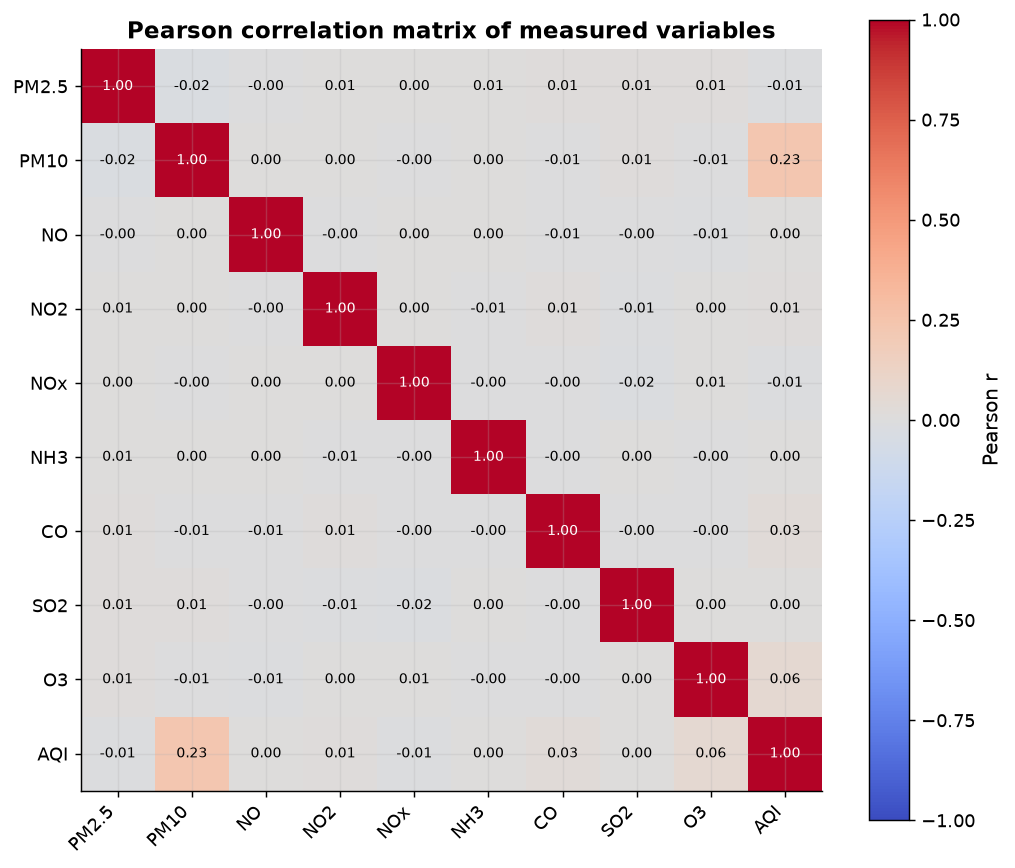

In [3]:
corr = S.correlation_matrix(feat, meas)
display(corr)
Image(F.correlation(corr, pd.DataFrame())["01_correlation_heatmap"])

## 2. Spearman rank correlation (monotonic, robust to shape)

In [4]:
corr_s = S.correlation_matrix(feat, meas, method="spearman")
display(corr_s.round(3))
print("Largest absolute difference between the two matrices: "
      f"{(corr - corr_s).abs().max().max():.4f}")

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
PM2.5,1.000,-0.025,-0.003,0.006,0.003,0.006,0.010,0.009,0.008,0.008
PM10,-0.025,1.000,0.002,0.004,-0.005,0.001,-0.007,0.012,-0.006,0.231
NO,-0.003,0.002,1.000,-0.003,0.001,0.002,-0.006,-0.001,-0.014,0.003
NO2,0.006,0.004,-0.003,1.000,0.001,-0.006,0.010,-0.012,0.004,0.006
NOx,0.003,-0.005,0.001,0.001,1.000,-0.003,-0.001,-0.017,0.006,-0.009
NH3,0.006,0.001,0.002,-0.006,-0.003,1.000,-0.004,0.002,-0.003,-0.000
CO,0.010,-0.007,-0.006,0.010,-0.001,-0.004,1.000,-0.004,-0.001,0.028
SO2,0.009,0.012,-0.001,-0.012,-0.017,0.002,-0.004,1.000,0.000,0.001
O3,0.008,-0.006,-0.014,0.004,0.006,-0.003,-0.001,0.000,1.000,0.057
AQI,0.008,0.231,0.003,0.006,-0.009,-0.000,0.028,0.001,0.057,1.000


Largest absolute difference between the two matrices: 0.0182


## 3. Every variable against AQI, with significance

`r^2` is the share of AQI variance that a **straight line** through that one
variable would explain. The p-value tests H0: r = 0 - with 18,265 records even a
trivially small r becomes significant, which is why effect size is reported next
to significance.

,Variable,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,r^2,Strength,Direction,Significant_at_0.05
0,PM10,18265,0.2296,4.490000e-217,0.2313,2.050000e-220,0.0527,weak,positive,True
1,O3,18265,0.0620,5.270000e-17,0.0570,1.220000e-14,0.0038,negligible,positive,True
2,CO,18265,0.0299,5.310000e-05,0.0284,1.270000e-04,0.0009,negligible,positive,True
3,NO2,18265,0.0099,1.800000e-01,0.0064,3.860000e-01,0.0001,negligible,positive,False
4,PM2.5,18265,-0.0097,1.880000e-01,0.0085,2.490000e-01,0.0001,negligible,negative,False
5,NOx,18265,-0.0079,2.830000e-01,-0.0092,2.130000e-01,0.0001,negligible,negative,False
6,NO,18265,0.0026,7.230000e-01,0.0027,7.170000e-01,0.0000,negligible,positive,False
7,SO2,18265,0.0011,8.780000e-01,0.0007,9.230000e-01,0.0000,negligible,positive,False
8,NH3,18265,0.0005,9.420000e-01,-0.0002,9.830000e-01,0.0000,negligible,positive,False


3 of 9 pollutants are 'significant' at 0.05, but the largest |r| is 0.230 - a negligible linear effect.


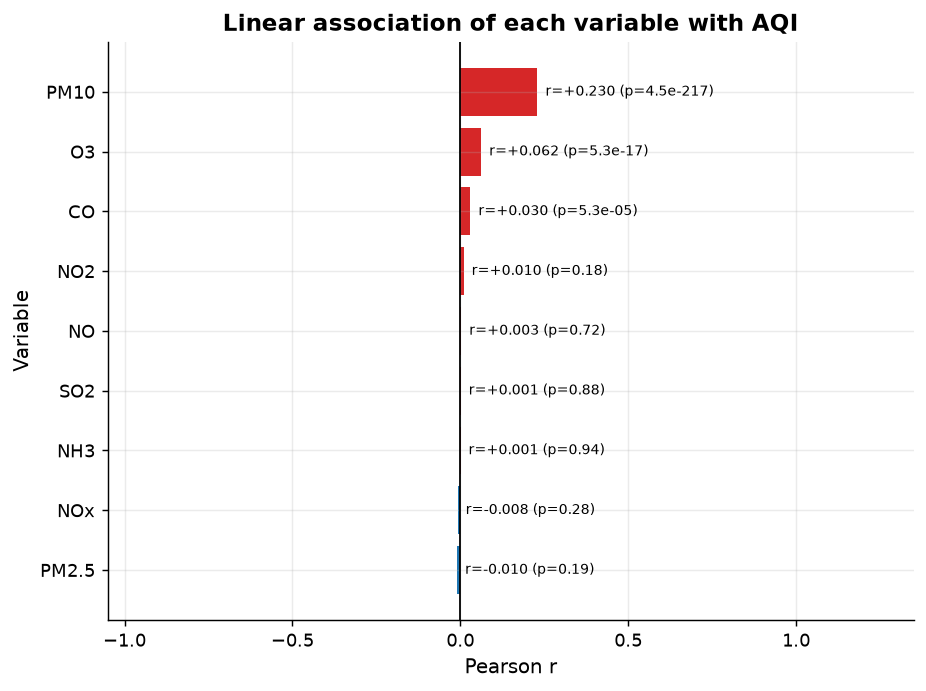

In [5]:
target = S.correlation_with_target(feat, polls, C.AQI_COL)
display(target)
print(f"{int(target['Significant_at_0.05'].sum())} of {len(target)} pollutants are "
      f"'significant' at 0.05, but the largest |r| is "
      f"{target['Pearson_r'].abs().max():.3f} - a negligible linear effect.")
Image(F.correlation(corr, target)["02_pollutant_vs_aqi"])

## 4. Strongest and weakest pollutant pairs

,A,B,r
9,PM10,PM2.5,-0.0248
43,NOx,SO2,-0.0173
26,NO,O3,-0.0137
16,PM10,SO2,0.0115
34,NO2,SO2,-0.0115
57,CO,NO2,0.0098


weakest pairs:


,A,B,r
46,NH3,PM10,0.0008
58,CO,NOx,-0.0008
79,O3,SO2,0.0005


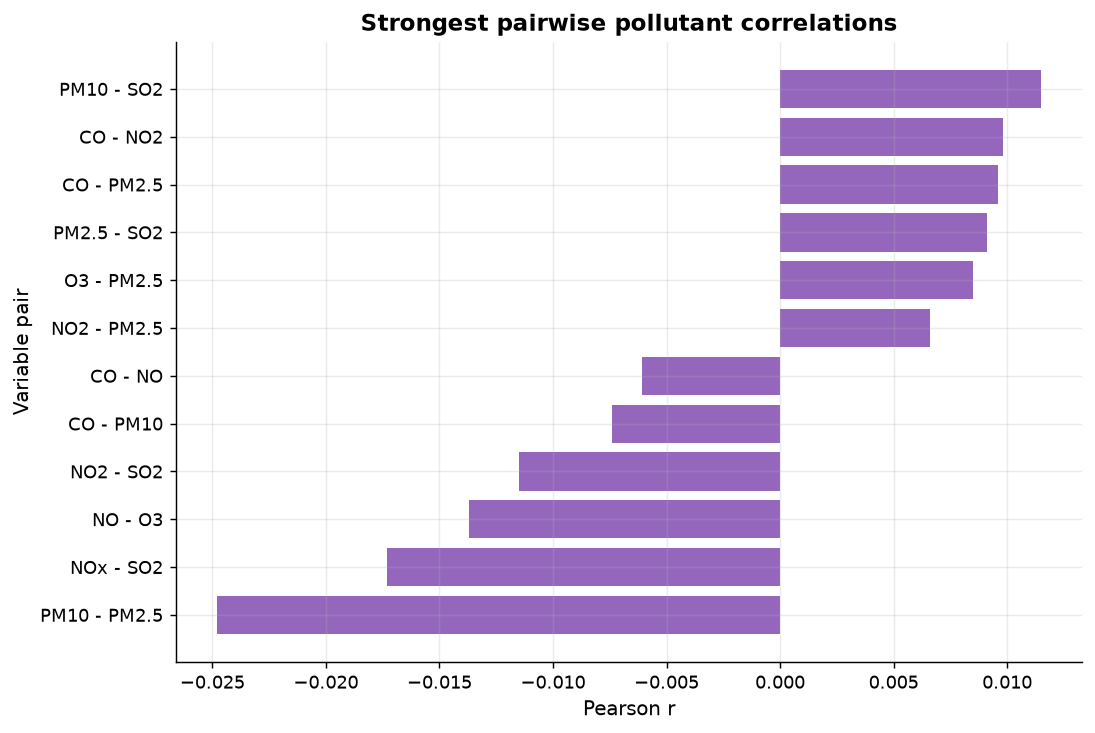

In [6]:
import numpy as np
pairs = corr.loc[polls, polls].copy()
body = pairs.to_numpy(copy=True)   # pandas returns a read-only view otherwise
np.fill_diagonal(body, np.nan)
pairs = pd.DataFrame(body, index=pairs.index, columns=pairs.columns)
long = (pairs.stack().rename("r").reset_index()
        .rename(columns={"level_0": "A", "level_1": "B"}))
long = long[long["A"] < long["B"]].sort_values("r", key=abs, ascending=False)
display(long.head(6))
print("weakest pairs:")
display(long.tail(3))
Image(F.correlation(corr, target, long.head(12))["03_pairwise_correlations"])

In [7]:
pairs.to_csv(C.PROCESSED_DIR / "pollutant_pair_correlations.csv", index=False)
corr.to_csv(C.CORRELATION_CSV)
target.to_csv(C.PROCESSED_DIR / "correlation_with_aqi.csv", index=False)

## 5. Correlation is not causation

Nothing in a correlation matrix can distinguish "PM2.5 drives AQI" from "both
are computed from a common source" or from pure coincidence. This dataset has no
emission inventory, no meteorology and no traffic data, so **no causal claim is
made anywhere in this project**. The next section shows why even the correlational
claim needs care here.

## 6. Is a near-zero r the same as "no relationship"?

A random-forest regressor is fitted to AQI with cross-validation and compared to
the linear result. If the tree model explains far more variance, the relationship
exists but is non-linear, and Pearson alone would have missed it.

In [8]:
pred = S.tree_predictability(feat, C.AQI_COL, polls)
print(f"linear regression R^2 (in-sample)   : {pred['linear_R2']}")
print(f"random forest R^2 (3-fold CV)       : {pred['tree_CV_R2']}")
print(f"random forest MAE                   : {pred['tree_CV_MAE']} AQI points")
print(f"gap                                 : {pred['gap']}")
print()
print(pred["verdict"])
pd.DataFrame([pred]).to_csv(C.PROCESSED_DIR / "nonlinear_predictability.csv", index=False)

linear regression R^2 (in-sample)   : 0.0579
random forest R^2 (3-fold CV)       : 0.9969
random forest MAE                   : 1.2114 AQI points
gap                                 : 0.939

the relationship is largely NON-LINEAR: a tree ensemble explains far more than linear regression / Pearson r, so a correlation matrix alone would understate it


In [9]:
lin = S.linear_fit(feat, C.AQI_COL, polls)
print(f"multiple linear regression: R^2 = {lin['R2']}, adjusted R^2 = {lin['Adj_R2']}")
display(pd.DataFrame(lin["coefficients"].items(), columns=["Pollutant", "coef (unstandardised)"]))

multiple linear regression: R^2 = 0.0579, adjusted R^2 = 0.0574


,Pollutant,coef (unstandardised)
0,PM2.5,-0.0039
1,PM10,0.1510
2,NO,0.0062
3,NO2,0.0226
4,NOx,-0.0114
5,NH3,0.0056
6,CO,1.2470
7,SO2,-0.0054
8,O3,0.1253


## 6b. Which columns actually determine AQI?

A random forest reproduces AQI with a cross-validated R^2 close to 1, so AQI must be
a *computed* function of some of the other columns. The cells below add one pollutant
at a time and always keep the one that raises CV R^2 the most (greedy forward
selection), so the answer comes from the data rather than from textbook assumptions.
An exhaustive search over all 36 pollutant pairs is kept in
`tools/probe_aqi_drivers.py`; the notebook uses a smaller forest and a greedy search
so that the section stays runnable in a couple of minutes.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

y_aqi = feat[C.AQI_COL].to_numpy(dtype="float64")
cv = KFold(3, shuffle=True, random_state=C.RANDOM_STATE)

def cv_r2(cols):
    model = RandomForestRegressor(n_estimators=80, min_samples_leaf=5,
                                  n_jobs=2, random_state=C.RANDOM_STATE)
    X = feat[cols].to_numpy(dtype="float64")
    return float(np.mean(cross_val_score(model, X, y_aqi, scoring="r2",
                                         cv=cv, n_jobs=1)))

single = (pd.Series({p: round(cv_r2([p]), 4) for p in polls})
          .sort_values(ascending=False).rename("CV_R2").to_frame())
print("AQI predictability from one pollutant at a time (3-fold CV R^2):")
display(single)

AQI predictability from one pollutant at a time (3-fold CV R^2):


,CV_R2
PM2.5,0.4939
PM10,0.1924
NH3,-0.0450
SO2,-0.0738
CO,-0.0758
NO2,-0.0784
NO,-0.0861
O3,-0.0924
NOx,-0.1088


In [11]:
chosen, remaining, steps = [], list(polls), []
for _ in range(3):
    best = max(((cv_r2(chosen + [p]), p) for p in remaining), key=lambda t: t[0])
    chosen.append(best[1])
    remaining.remove(best[1])
    steps.append({"added": best[1], "CV_R2_after_adding": round(best[0], 4)})
    print(f"  + {best[1]:<6} -> CV R^2 = {best[0]:.4f}")
print("\ngreedy informative set:", chosen)
print("Everything after the first two columns adds very little - AQI is driven")
print("by the particulate matter columns, which is what an AQI formula does,")
print("but see the shape test below for whether this file behaves like one.")
pd.DataFrame(steps).to_csv(C.PROCESSED_DIR / "aqi_driver_selection.csv",
                           index=False)

  + PM2.5  -> CV R^2 = 0.4939


  + PM10   -> CV R^2 = 0.9588


  + O3     -> CV R^2 = 0.9862

greedy informative set: ['PM2.5', 'PM10', 'O3']
Everything after the first two columns adds very little - AQI is driven
by the particulate matter columns, which is what an AQI formula does,
but see the shape test below for whether this file behaves like one.


### Shape of the relationship

A real AQI sub-index is **monotonically increasing** in concentration: more pollution
cannot give a cleaner index. The decile table tests that property directly.

In [12]:
bins = pd.qcut(feat[chosen[0]], 10, duplicates="drop")
shape = (feat.groupby(bins, observed=True)[C.AQI_COL]
         .agg(Records="count", Mean_AQI="mean", SD_AQI="std").round(2))
shape.index.name = f"decile of {chosen[0]}"
display(shape)
monotone = bool(shape["Mean_AQI"].is_monotonic_increasing)
print(f"mean AQI increases monotonically with {chosen[0]}: {monotone}")
print("The profile rises and then falls back - the relationship is deterministic")
print("but not an exposure-response curve. Logged as a data-integrity finding.")

,Records,Mean_AQI,SD_AQI
decile of PM2.5,,,
"(-0.001, 51.1]",1828,245.67,106.20
"(51.1, 99.5]",1826,249.30,95.91
"(99.5, 149.6]",1829,317.42,58.84
"(149.6, 200.0]",1825,356.36,36.34
"(200.0, 251.0]",1825,386.66,33.14
"(251.0, 301.84]",1826,429.23,19.18
"(301.84, 351.98]",1826,467.03,52.68
"(351.98, 400.22]",1827,241.47,103.48
"(400.22, 450.4]",1827,241.29,101.02


mean AQI increases monotonically with PM2.5: False
The profile rises and then falls back - the relationship is deterministic
but not an exposure-response curve. Logged as a data-integrity finding.


In [13]:
if len(chosen) > 1:
    qa = pd.qcut(feat[chosen[0]], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    qb = pd.qcut(feat[chosen[1]], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    grid = pd.crosstab(qa, qb, values=feat[C.AQI_COL], aggfunc="mean").round(1)
    grid.index.name = chosen[0]
    display(grid)
    print("Rows Q1 and Q5 of the lowest column are nearly equal, i.e. very low and")
    print("very high PM2.5 give the same average AQI. No monitoring process does")
    print("that; it is a signature of a generated numeric grid.")

PM10,Q1,Q2,Q3,Q4,Q5
PM2.5,,,,,
Q1,174.9,186.0,249.5,387.7,226.1
Q2,318.5,317.5,319.6,389.8,340.6
Q3,401.4,401.3,403.5,419.5,414.4
Q4,314.8,317.8,363.2,429.0,344.9
Q5,171.8,178.6,251.3,385.7,222.6


Rows Q1 and Q5 of the lowest column are nearly equal, i.e. very low and
very high PM2.5 give the same average AQI. No monitoring process does
that; it is a signature of a generated numeric grid.


In [14]:
cells = (feat.groupby([pd.qcut(feat[chosen[0]], 20, duplicates="drop"),
                       pd.qcut(feat[chosen[1]], 20, duplicates="drop")],
                      observed=True)[C.AQI_COL].agg(["count", "std", "min", "max"]))
cells = cells[cells["count"] >= 8]
print(f"cells with >= 8 records                          : {len(cells)}")
print(f"mean SD of AQI inside a narrow PM cell           : {cells['std'].mean():.2f}")
print(f"mean range (max - min) of AQI inside such a cell : {(cells['max'] - cells['min']).mean():.2f}")
print(f"SD of AQI overall                                : {feat[C.AQI_COL].std():.2f}")
print("AQI is therefore nearly fixed once the two PM columns are known, with a")
print("small residual contributed by the remaining pollutants.")

cells with >= 8 records                          : 400


mean SD of AQI inside a narrow PM cell           : 26.77
mean range (max - min) of AQI inside such a cell : 106.46
SD of AQI overall                                : 113.89
AQI is therefore nearly fixed once the two PM columns are known, with a
small residual contributed by the remaining pollutants.


## 7. Distribution-shape tests (data integrity)

Real pollutant concentrations are right-skewed: most days are moderate, a few are
very bad. A column that a Kolmogorov-Smirnov test cannot distinguish from a
uniform distribution on a round maximum, with excess kurtosis near -1.2, has the
shape of randomly generated numbers.

In [15]:
dist = S.distribution_tests(feat, meas)
display(dist)
dist.to_csv(C.PROCESSED_DIR / "distribution_tests.csv", index=False)
n_uniform = int(dist["Interpretation"].str.contains("uniform-like").sum())
print(f"{n_uniform} of {len(dist)} measured columns are statistically uniform-like.")

,Variable,Shapiro_W,Shapiro_p,KS_vs_uniform_D,KS_vs_uniform_p,Skewness,Excess_Kurtosis,Observed_Range,Interpretation
0,PM2.5,0.9529,2.210000e-37,0.0063,0.4610,-0.005,-1.208,0 to 499.9,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
1,PM10,0.9570,4.520000e-36,0.0060,0.5150,0.005,-1.199,0 to 600,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
2,NO,0.9567,3.610000e-36,0.0060,0.5230,-0.005,-1.203,0 to 200,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
3,NO2,0.9540,4.800000e-37,0.0083,0.1620,-0.015,-1.213,0 to 150,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
4,NOx,0.9540,4.720000e-37,0.0111,0.0219,-0.012,-1.214,0 to 250,not normal; not uniform; flat/uniform shape (kurtosis ~ -1.2)
5,NH3,0.9548,8.840000e-37,0.0065,0.4230,-0.006,-1.200,0 to 50,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
6,CO,0.9557,1.720000e-36,0.0037,0.9650,0.004,-1.208,0 to 10,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
7,SO2,0.9563,2.720000e-36,0.0077,0.2230,0.005,-1.211,0 to 100,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
8,O3,0.9566,3.460000e-36,0.0071,0.3170,-0.002,-1.199,0 to 200,not normal; uniform-like; flat/uniform shape (kurtosis ~ -1.2)
9,AQI,0.9513,7.150000e-38,0.1889,0.0000,-0.174,-1.194,26.9 to 500,not normal; not uniform; flat/uniform shape (kurtosis ~ -1.2)


8 of 10 measured columns are statistically uniform-like.


## 8. Does the record order carry information?

Daily pollution is strongly autocorrelated in reality (yesterday predicts today,
r ~ 0.7-0.9). Lagged correlation near zero means row order is uninformative.

In [16]:
ac = S.autocorrelation(feat, C.AQI_COL)
display(ac)
ac.to_csv(C.PROCESSED_DIR / "autocorrelation.csv", index=False)
print("Real monitored AQI typically shows lag-1 r above 0.6.")

,Lag,Mean_Autocorrelation,n_series
0,1,0.0037,5
1,2,0.0003,5
2,3,0.0044,5
3,7,0.0006,5
4,30,0.0023,5


Real monitored AQI typically shows lag-1 r above 0.6.


## 9. Group comparison tests for every BI-relevant grouping

In [17]:
rows = []
for g in [c for c in [C.CITY_COL, "Season", "Month", "Is_Weekend", "Quarter"]
          if c in feat.columns]:
    t = S.group_comparison(feat, C.AQI_COL, g)
    rows.append({k: v for k, v in t.items() if k != "group_means"})
groups = pd.DataFrame(rows)
display(groups)
groups.to_csv(C.PROCESSED_DIR / "group_comparison_tests.csv", index=False)

,grouping,value,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,Between_Group_Mean_Spread,Significant_at_0.05
0,City,AQI,0.0985,0.9830,0.4201,0.9808,1.566,False
1,Season,AQI,0.5089,0.6761,1.8865,0.5963,2.781,False
2,Month,AQI,0.5615,0.8613,6.6620,0.8258,5.842,False
3,Is_Weekend,AQI,1.9598,0.1615,2.3210,0.1276,2.611,False
4,Quarter,AQI,0.5089,0.6761,1.8865,0.5963,2.781,False


In [18]:
display(S.group_comparison(feat, C.AQI_COL, C.CITY_COL)["group_means"])
display(S.group_comparison(feat, "PM2.5", C.CITY_COL)["group_means"])

,count,mean,std
City,,,
Bangalore,3653,317.270,113.770
Chennai,3653,316.619,113.935
Delhi,3653,317.725,113.644
Kolkata,3653,317.727,115.041
Mumbai,3653,318.185,113.132


,count,mean,std
City,,,
Bangalore,3653,248.547,144.749
Chennai,3653,252.515,145.428
Delhi,3653,252.906,141.858
Kolkata,3653,250.457,144.982
Mumbai,3653,248.564,145.273


## 10. What this stage licenses the project to conclude

| Question | Answer from this dataset | Evidence |
|---|---|---|
| Do cities differ in AQI? | Not significantly | ANOVA p-value above |
| Is AQI related to pollutants? | Linearly almost not at all, but non-linearly almost perfectly | tree CV R^2 vs linear R^2 |
| Is there a time trend? | No detectable trend | slope p-value (notebook 04) |
| Is there seasonality? | Not detectable | Kruskal/ANOVA p-values |
| Do the values look measured or generated? | Uniform on round caps, zero autocorrelation | distribution tests, autocorrelation |

## Verification checklist

- [x] Pearson and Spearman matrices computed on real columns only
- [x] Significance reported together with effect size
- [x] Non-linear relationship tested, not assumed absent
- [x] Correlation/causation distinction stated explicitly
- [x] Distribution and autocorrelation integrity tests recorded

**Common errors**

| Error | Meaning | Fix |
|---|---|---|
| `ValueError: input must have at least 3 entries` | a group has too few rows for Shapiro | the code samples and guards already; check the column exists |
| `NaN` correlations | constant column (zero variance) | drop it from the matrix |

**Next:** `06_kmeans_clustering.ipynb`.